<Axes: >

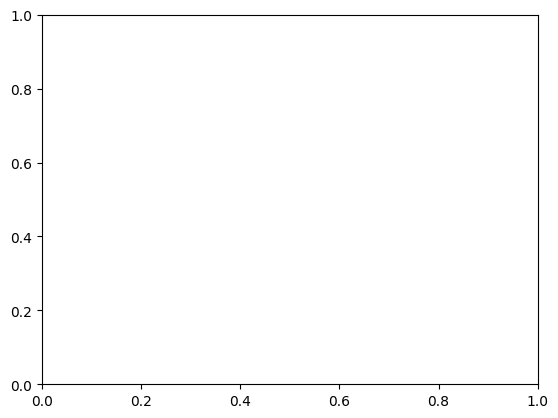

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.subplot()

In [25]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns

from cartm.model import ContextTopicModel
#from cartm.attentive_model import AttentiveTopicModel
from cartm.improved_model import AttentiveTopicModel
from cartm.preprocessing import DatasetPreprocessor

This example will guide you through the basic interaction with the model.

## Data preprocessing

First, let's download a sample dataset and preprocess it with `DatasetPreprocessor`.

In [37]:
data = fetch_20newsgroups(data_home='./data/', subset='all').data
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 18846
Total number of words in corpus: 5937230


In [38]:
data = data[:400]

In [36]:
with open('./data/test_data.txt') as f:
    data = f.readlines()
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 4
Total number of words in corpus: 34


In [39]:
preprocessor = DatasetPreprocessor(stopwords=[], min_word_len=0)
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of document boundaries in preprocessed corpus: {len(document_bounds)}')
print(f'Total number of tokenized words in preprocessed corpus: {len(tokenized_data)}')

Total number of document boundaries in preprocessed corpus: 401
Total number of tokenized words in preprocessed corpus: 96398


The `DatasetPreprocessor` class handles the filtering and tokenizing of the raw data. Its method `fit_transform` learns the vocabulary of the passed corpus of documents and returns tokenized words from corpus as the first return value, and document bounds as the second return value.

By default, `DatasetPreprocessor` removes stopwords, digits and special characters, therefore the total number of tokenized words is less than the number of words in raw corpus. Document boundaries are at the beginning and ending of the document, therefore the number of boundaries is [number_of_documents] + 1.

The returned values from `fit_transform` have jax.numpy.ndarray type, so you can work with them like a normal arrays.

In [40]:
print(f'Number of unique words in the preprocessed corpus: {jnp.max(tokenized_data)}')

Number of unique words in the preprocessed corpus: 10021


### Accessing vocabulary

You can also access mapping of words to tokens after fitting the preprocessor with data.

In [41]:
vocabulary = preprocessor.vocabulary

for i, (word, token) in enumerate(vocabulary.items()):
    print(f'{word}: {token}')
    if i == 10:
        break

reverse_vocab = {value: key for key, value in vocabulary.items()}
#[reverse_vocab[t] for t in tokenized_data.tolist()]

analges: 0
mcdiarmid: 1
band: 2
remind: 3
cdn: 4
onc: 5
wast: 6
predat: 7
older: 8
casey: 9
reincarn: 10


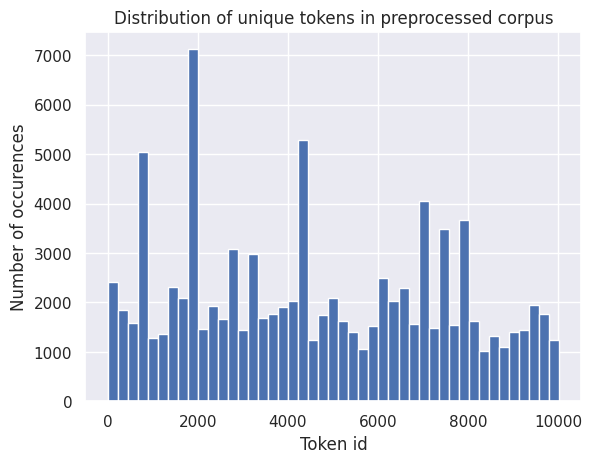

In [42]:
sns.set_theme()

#plt.hist(tokenized_data, bins=100)
plt.hist(tokenized_data, bins='auto')

plt.xlabel('Token id')
plt.ylabel('Number of occurences')
plt.title('Distribution of unique tokens in preprocessed corpus')
#plt.yscale('log')
plt.show()

[('the', np.int64(4317)), ('to', np.int64(2112)), ('of', np.int64(1959)), ('a', np.int64(1845)), ('and', np.int64(1616)), ('i', np.int64(1567)), ('in', np.int64(1448)), ('is', np.int64(1262)), ('that', np.int64(1138)), ('it', np.int64(995))]
96398


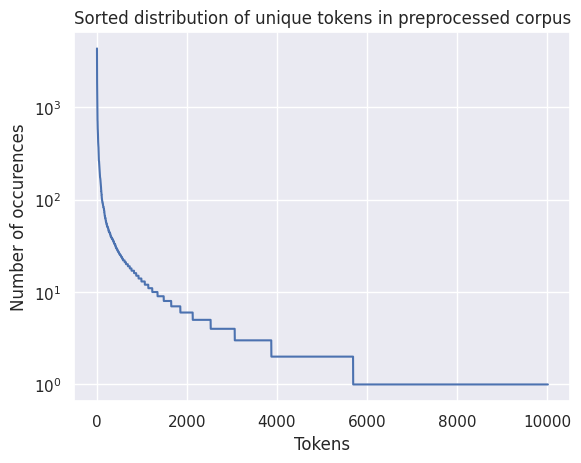

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
data = tokenized_data
tokens, counts = np.unique(tokenized_data, return_counts=True)
sorted_indices = np.argsort(counts)[::-1]
sorted_counts = counts[sorted_indices]
sorted_tokens = tokens[sorted_indices]

print([(reverse_vocab[sorted_tokens[i]], sorted_counts[i]) for i in range(10)])
print(sum(sorted_counts))

plt.plot(sorted_counts)
plt.yscale('log')
plt.xlabel('Tokens')
plt.ylabel('Number of occurences')
plt.title('Sorted distribution of unique tokens in preprocessed corpus')
plt.show()

## Model training

Having the data preprocessed with `DatasetPreprocessor`, we can fit out model pretty straighforwardly.

Please note that calling `fit` method multiple times in one model will discard all results of the previous training.

In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
topic_model = AttentiveTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=10
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
)

E0405 22:05:50.613333  609758 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.7 = f32[10022,10]{1,0} fusion(div.60, reduce.1, phi.1), kind=kCustom, calls=gemm_fusion_dot_general.7_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0405 22:05:50.613452  609758 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.7_computation.clone {
  parameter_2 = f32[10022,10]{1,0} parameter(2)
  parameter_1 = f32[96398,10022]{1,0} parameter(1)
  parameter_0 = f32[96398,10]{1,0} parameter(0)
  dot.1 = f32[10022,10]{1,0} dot(parameter_1, parameter_0), lhs_contracting_dims={0}, rhs_contracting_dims={0}, backend_config={"sizes":

Iteration [1/1000], phi update diff norm: 37.2041
Iteration [2/1000], phi update diff norm: 7.9297
Iteration [3/1000], phi update diff norm: 9.5598
Iteration [4/1000], phi update diff norm: 11.3761
Iteration [5/1000], phi update diff norm: 12.1165
Iteration [6/1000], phi update diff norm: 11.6992
Iteration [7/1000], phi update diff norm: 10.9444
Iteration [8/1000], phi update diff norm: 10.1045
Iteration [9/1000], phi update diff norm: 9.1959
Iteration [10/1000], phi update diff norm: 8.3142
Iteration [11/1000], phi update diff norm: 7.5995
Iteration [12/1000], phi update diff norm: 6.8950
Iteration [13/1000], phi update diff norm: 6.3137
Iteration [14/1000], phi update diff norm: 5.9458
Iteration [15/1000], phi update diff norm: 5.6503
Iteration [16/1000], phi update diff norm: 5.4776
Iteration [17/1000], phi update diff norm: 5.2527
Iteration [18/1000], phi update diff norm: 4.9115
Iteration [19/1000], phi update diff norm: 4.5558
Iteration [20/1000], phi update diff norm: 4.3765
Ite

In [46]:
topic_model.phi

Array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 6.6388607e-01, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 3.3611399e-01],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 0.0000000e+00],
       ...,
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.7967295e-02,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 1.0385637e-32, 0.0000000e+00, ..., 7.7282494e-01,
        0.0000000e+00, 2.2717507e-01],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

The model training stops because the update diff norm becomes too low. This means that the model has converged. You can modify the convergence threshold and max number of iterations.

You can also modify number of topics and other parameters of the model. Refer to the `fit` funciton docs for more info about model training.

## Analysis

After the model is fitted, you can access its parameters and analyse them.

In [35]:
phi_wt = topic_model.phi  # p(w|t)
n_t = topic_model.n_t  # denormalized distribution of topics
print(f'phi matrix type: {type(phi_wt)}, shape: {phi_wt.shape}')
print(f'n_t array type: {type(n_t)}, shape: {n_t.shape}')

phi matrix type: <class 'jaxlib._jax.ArrayImpl'>, shape: (90883, 10)
n_t array type: <class 'jaxlib._jax.ArrayImpl'>, shape: (10,)


### Plot a histogram of a distribution of topics in corpus:

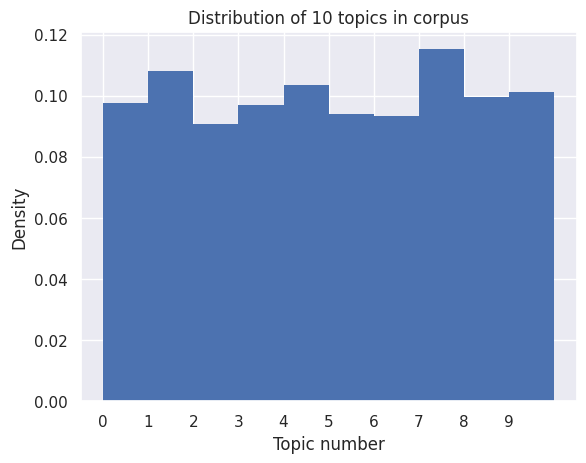

In [36]:
plt.stairs(n_t / n_t.sum(), range(len(n_t) + 1), fill=True)

plt.xticks(range(len(n_t)))
plt.xlabel('Topic number')
plt.ylabel('Density')
plt.title('Distribution of 10 topics in corpus')
plt.show()

### Print top-10 words from each topic:

In [37]:
# find top-10 words with the biggest probability p(w|t) for each topic t
topk = jnp.argsort(phi_wt, axis=0, descending=True)[:20, :].T

# create mapping token -> word from existing mapping word -> token (vocabulary)
reverse_vocab = {value: key for key, value in vocabulary.items()}

for topic_idx, t in enumerate(topk):
    print(f'Topic {topic_idx + 1}:', '\t'.join([reverse_vocab[int(idx)] for idx in t]))
    print()

Topic 1: wama	abab	viy	stade	unmitig	kzoo	stave	pem	chua	nikolayef	ocu	kalki	faraday	delaer	mispres	gvolk	vestnik	kwg	sjw	qljjhv

Topic 2: lhvnzv	undercook	lnk	nsfb	victim	mpeg	dubili	endem	chia	hewlett	cdx	contribut	lynda	samba	rrrraggggah	mcammond	baw	desertif	sulfatrim	vmi

Topic 3: leviticu	sheffner	bbss	walsteyn	unspecifi	fabl	voordrachten	splung	tlu	gruesom	saathi	fedorovich	qvrnpinnnid	crossan	defaria	tcwn	cntf	catagor	nck	awri

Topic 4: remmon	apsevokoitai	puke	voicetyp	forfeit	lineno	bobo	tni	trickl	mopar	vumrlh	quran	knu	fahss	baculum	harangu	partook	tanya	begin	miniscul

Topic 5: pvyn	fkx	noj	drama	gbj	rug	sylvain	ferment	niether	baseless	murillo	ahaley	shelli	wordprocess	chasten	outlook	templar	ijzna	kalivoda	rosencran

Topic 6: heret	suspend	neogoti	nonk	listr	strandard	qtrz	chung	ncn	mmzvm	colo	oxen	benito	meft	jarthur	fowt	reencod	lcdn	eed	unsaf

Topic 7: xtinstallacceler	janvopv	diskman	bale	downsid	zeil	chungi	anorexia	cleveland	cfront	bodyguard	psg	paidomath	sabo	stan

In [38]:
from jax import jit

@jit
def entropy_renyi(matrix, power):
    entropies = jnp.sum(matrix ** power, axis=1)
    return entropies    
    #return jnp.sort(entropies) / jnp.max(entropies)

In [39]:
entropys = [(s, entropy_renyi(phi_wt, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
print(f"{entropys=}")
cum_entropys = []


entropys=[(np.float64(1.1), Array([1.        , 0.99999994, 1.        , ..., 1.        , 1.        ,
       0.99999994], dtype=float32)), (np.float64(1.2000000000000002), Array([1.        , 0.99999994, 1.        , ..., 1.        , 1.        ,
       0.99999994], dtype=float32)), (np.float64(1.3), Array([1.        , 0.99999994, 1.        , ..., 1.        , 1.        ,
       0.99999994], dtype=float32)), (np.float64(1.4), Array([1.        , 0.99999994, 1.        , ..., 1.        , 1.        ,
       0.99999994], dtype=float32)), (np.float64(1.5), Array([1.        , 0.99999994, 1.        , ..., 1.        , 1.        ,
       0.99999994], dtype=float32)), (np.float64(1.6), Array([1.       , 0.9999999, 1.       , ..., 1.       , 1.       ,
       0.9999999], dtype=float32)), (np.float64(1.7), Array([1.       , 0.9999999, 1.       , ..., 1.       , 1.       ,
       0.9999999], dtype=float32)), (np.float64(1.7999999999999998), Array([1.       , 0.9999999, 1.       , ..., 1.       , 1.       

In [46]:
print(f"{phi_wt[0]=}")
print(f"{reverse_vocab[0]=}")
print(f"{phi_wt[1]=}")
print(f"{reverse_vocab[1]=}")
sum([p_t**1.1 for p_t in phi_wt[1]])

phi_wt[0]=Array([3.5004224e-26, 1.1834980e-38, 1.2807735e-25, 3.8974366e-26,
       3.4447159e-35, 2.8307551e-35, 2.5801001e-30, 2.5194796e-27,
       0.0000000e+00, 1.0000000e+00], dtype=float32)
reverse_vocab[0]='polari'
phi_wt[1]=Array([4.60942392e-24, 1.34670121e-23, 1.31132866e-21, 2.09017190e-30,
       1.80185262e-39, 9.99999940e-01, 2.74413807e-34, 1.01267240e-31,
       1.04797696e-35, 7.87424624e-26], dtype=float32)
reverse_vocab[1]='constel'


Array(0.99999994, dtype=float32)

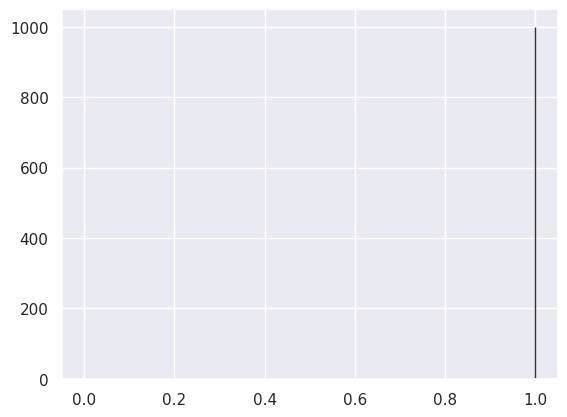

In [43]:
counts, bin_edges, _ = plt.hist(
    entropys[5][1], 
    bins=1000, 
    range=(0, 1),  # фиксированный диапазон
    density=True,
    color='b', 
    edgecolor='black',
    alpha=0.8,
    label='Распределение'
)


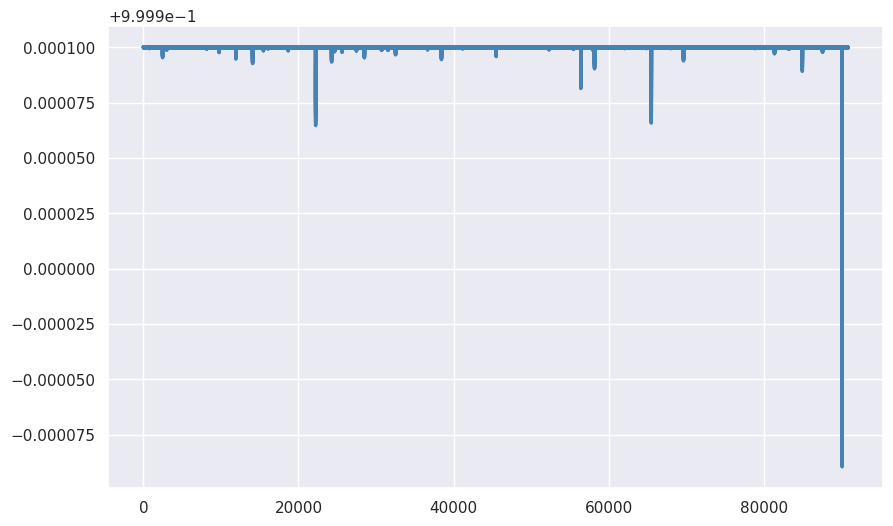

In [44]:

plt.figure(figsize=(10, 6))
for s, entropy in entropys:
    plt.plot(entropy, 
        linestyle='-', linewidth=2.5, markersize=8,
        color='steelblue', markerfacecolor='white', markeredgecolor='steelblue')


In [126]:
def plot_distribution_advanced(data, n_bins=20, figsize=(12, 5), 
                              plot_type='all', bandwidth=None):
    """
    Расширенная визуализация распределения.
    
    Args:
        data: 1D массив чисел в [0, 1]
        n_bins: количество бинов для гистограммы
        figsize: размер фигуры
        plot_type: 'hist' | 'kde' | 'ecdf' | 'all'
        bandwidth: ширина окна для KDE (по умолчанию автоматический выбор)
    
    Returns:
        dict с данными для каждого типа графика
    """
    data = np.asarray(data)
    n = len(data)
    
    results = {}
    
    # === ГИСТОГРАММА ===
    if plot_type in ['hist', 'all']:
        fig, ax = plt.subplots(figsize=figsize)
        counts, bin_edges, _ = ax.hist(
            data, bins=n_bins, range=(0, 1), density=True,
            color='skyblue', edgecolor='black', alpha=0.7, label='Гистограмма'
        )
        ax.set_xlabel('Значение', fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        ax.set_title('Гистограмма распределения', fontsize=13, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        results['hist'] = {'counts': counts, 'bin_edges': bin_edges}
    
    # === KDE (ядерная оценка плотности) ===
    if plot_type in ['kde', 'all']:
        from scipy.stats import gaussian_kde
        
        # Автоматический bandwidth, если не задан
        if bandwidth is None:
            bandwidth = 1.06 * data.std() * n ** (-1/5)  # правило Сильвермана
        
        # Оценка плотности
        x_eval = np.linspace(0, 1, 200)
        kde = gaussian_kde(data, bw_method=bandwidth / data.std() if data.std() > 0 else 1.0)
        # Обрезаем выбросы KDE за пределами [0, 1]
        density = kde(x_eval)
        density = np.where((x_eval >= 0) & (x_eval <= 1), density, 0)
        
        plt.figure(figsize=figsize)
        plt.plot(x_eval, density, linewidth=2.5, color='darkorange', label='KDE')
        plt.fill_between(x_eval, density, alpha=0.2, color='darkorange')
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Плотность', fontsize=11)
        plt.title('Ядерная оценка плотности (KDE)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['kde'] = {'x': x_eval, 'density': density}
    
    # === ECDF (эмпирическая функция распределения) ===
    if plot_type in ['ecdf', 'all']:
        sorted_data = np.sort(data)
        ecdf = np.arange(1, n + 1) / n
        
        plt.figure(figsize=figsize)
        plt.plot(sorted_data, ecdf, linewidth=2, color='darkgreen', label='ECDF')
        plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Медиана')
        plt.axvline(x=np.median(data), color='red', linestyle=':', alpha=0.5)
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Накопленная доля', fontsize=11)
        plt.title('Эмпирическая функция распределения (ECDF)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['ecdf'] = {'x': sorted_data, 'ecdf': ecdf}
    
    # Статистика
    #print(f"📊 Статистика данных (n={n})")
    #print(f"   Мин: {data.min():.4f}, Макс: {data.max():.4f}")
    #print(f"   Среднее: {data.mean():.4f}, Медиана: {np.median(data):.4f}")
    #print(f"   Стд. отклонение: {data.std():.4f}")
    #print(f"   Квантили: 25%={np.percentile(data, 25):.4f}, "
    #      f"75%={np.percentile(data, 75):.4f}")
    
    #return results

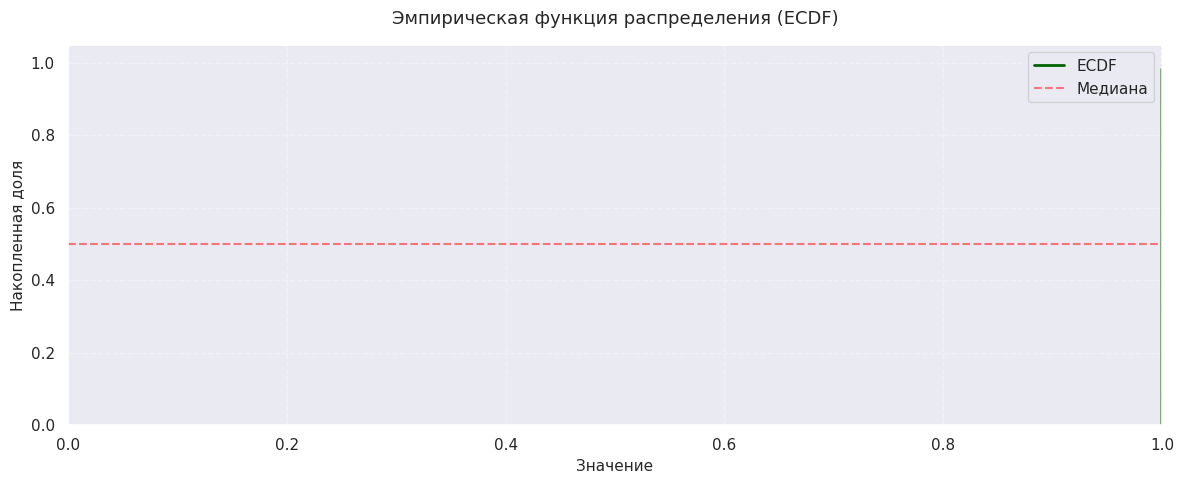

In [206]:
# Разные типы распределений для теста
data_uniform = np.random.uniform(0, 1, 1000)      # равномерное
data_beta = np.random.beta(2, 5, 1000)            # скошено вправо
data_bimodal = np.concatenate([
    np.random.beta(2, 2, 500) * 0.4,              # левый пик
    np.random.beta(2, 2, 500) * 0.4 + 0.6         # правый пик
])

# Построение всех типов графиков
plot_distribution_advanced(entropys[0][1], plot_type='ecdf')

In [47]:
vocabulary['the']

40986

In [48]:
phi_wt[40986]

Array([8.2978104e-28, 3.0296654e-27, 7.3995615e-28, 2.9136755e-24,
       1.7510158e-27, 6.9659037e-24, 3.1309051e-28, 9.9999994e-01,
       6.1273859e-26, 6.5633631e-30], dtype=float32)

In [50]:
l = [
    [1, 2, 3],
    [3, 4, 5]
]
ja = jnp.array(l)
ja.shape

(2, 3)